# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**Answer:** 17

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
# load in the initial set of packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC



In [2]:
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')


In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
# check for missing values
df.isna().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [6]:
df.dtypes


age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Categories stored as object, numeric columns are in or float, no datetime columns, several str columns, no booleans.

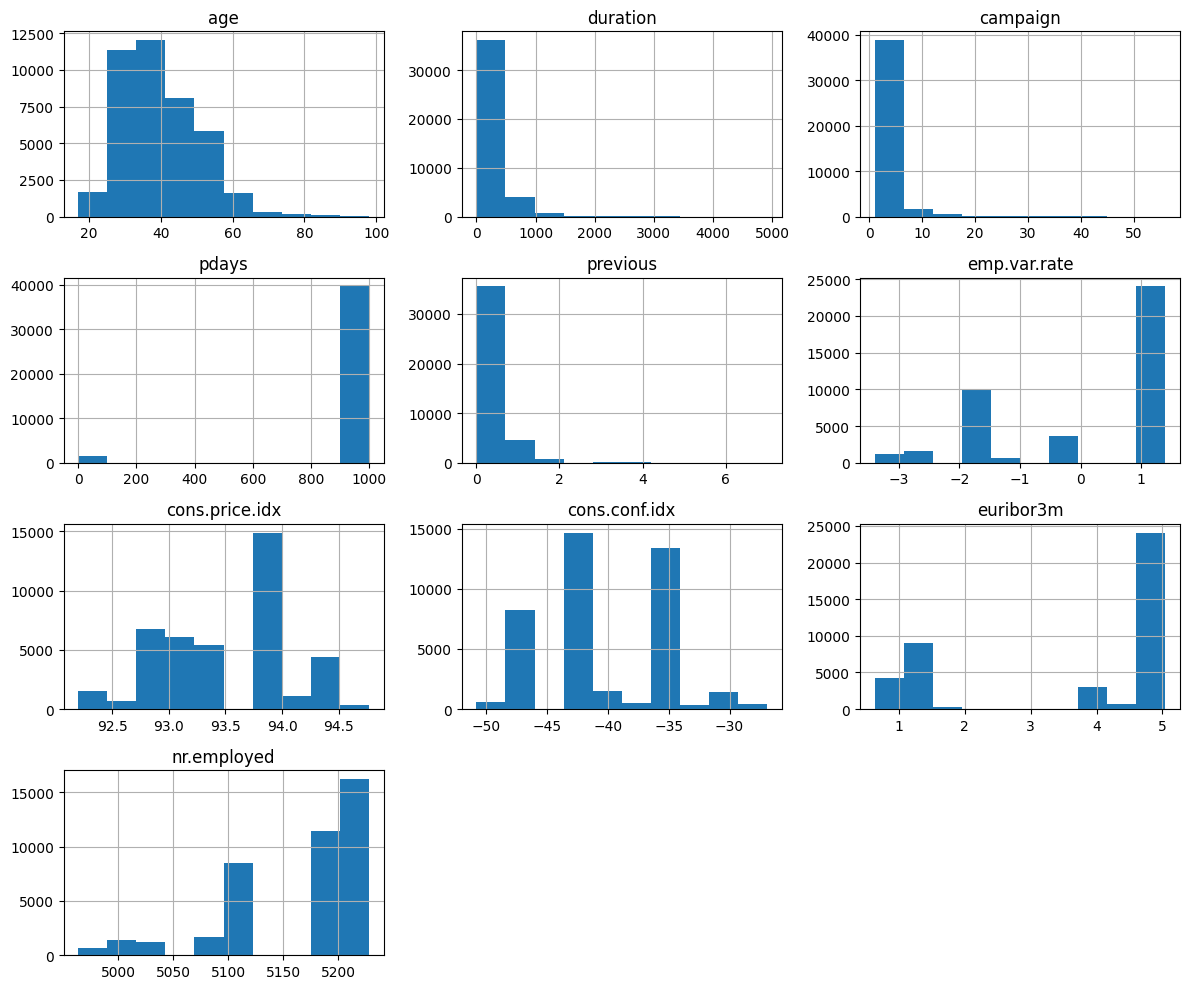

In [7]:
#Let's visualize the data
df.select_dtypes(include=['int64','float64']).hist(figsize=(12,10))
plt.tight_layout()
plt.show()


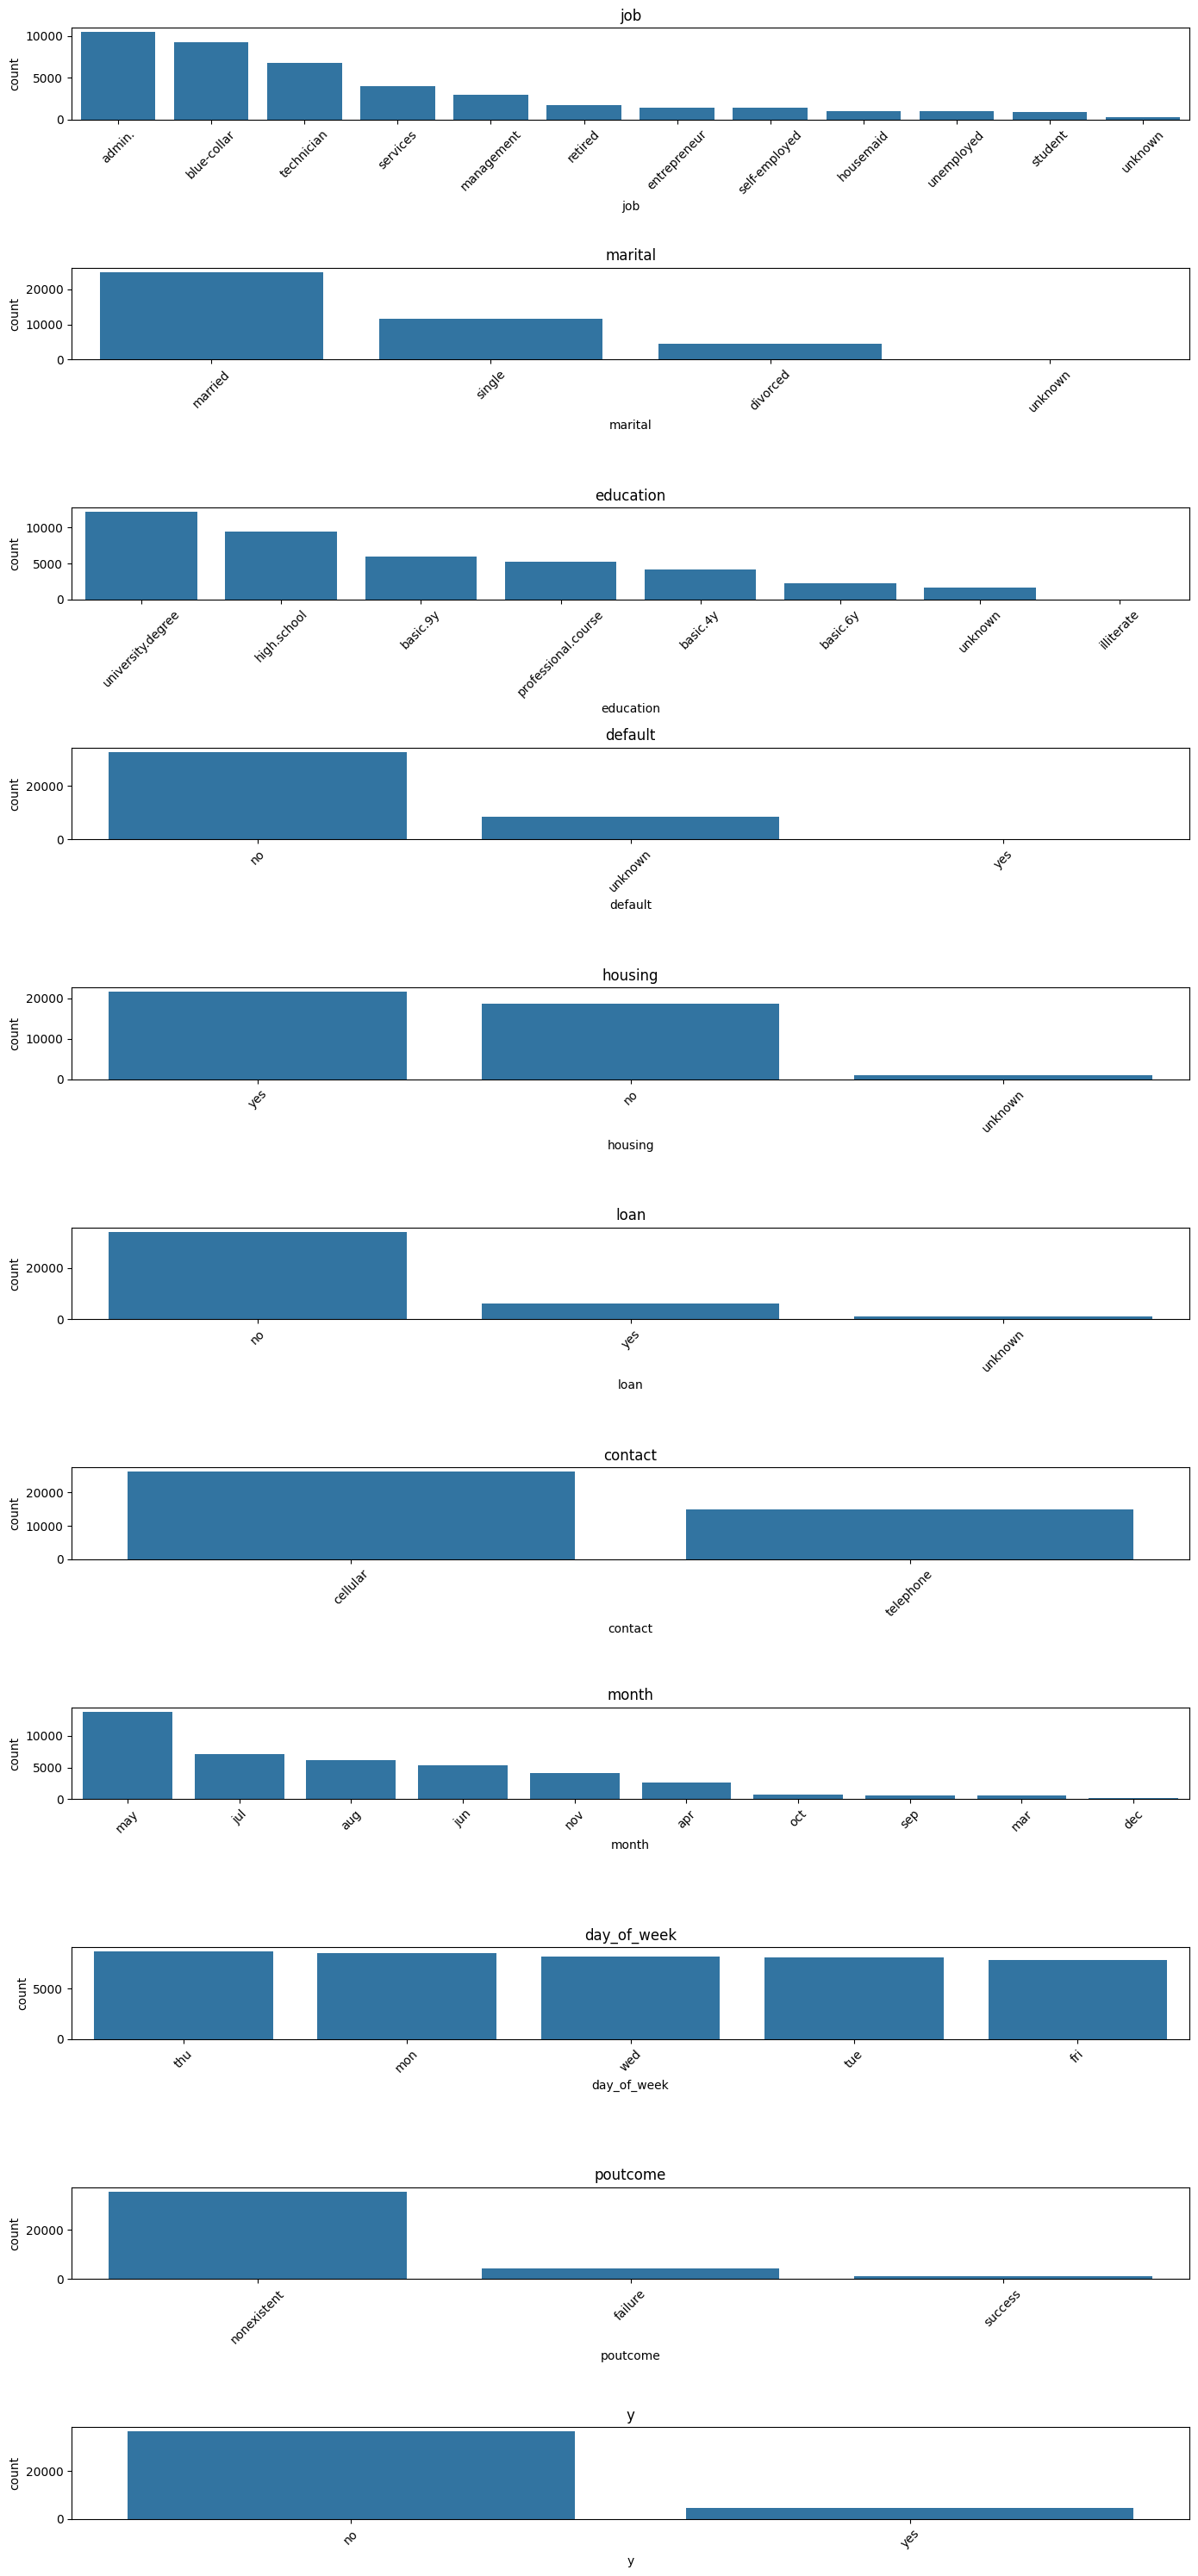

In [9]:
# now visualize category data
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = df.select_dtypes(include=['object', 'string', 'category']).columns

plt.figure(figsize=(14, 30))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(len(categorical_cols), 1, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


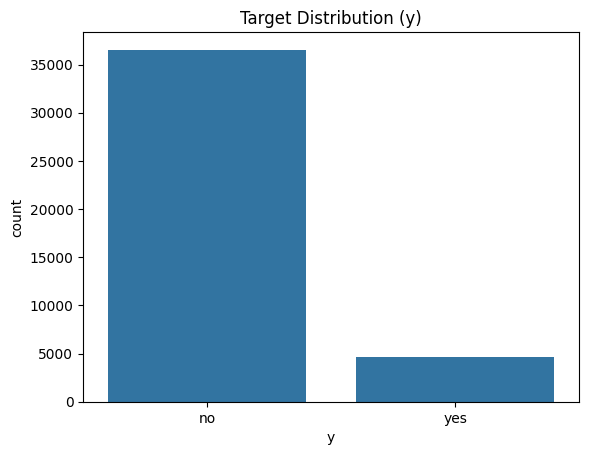

In [11]:
#Visualize target variable
sns.countplot(data=df, x='y')
plt.title("Target Distribution (y)")
plt.show()


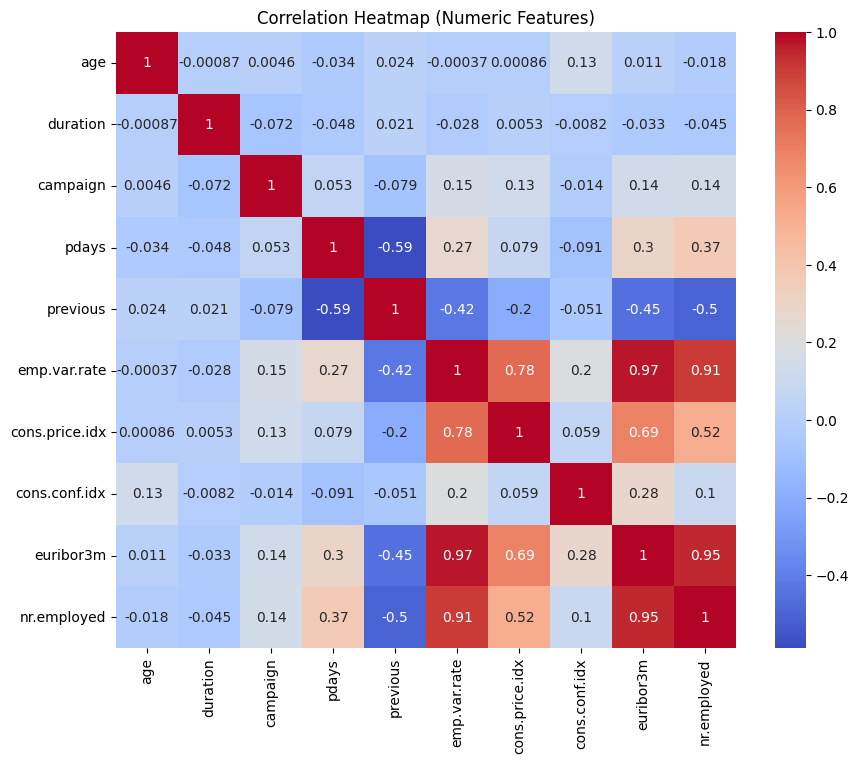

In [13]:
# visualize correlation heat map
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**What marketing attributes lead to the highest bank subscriptions?**

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [4]:
# --- 1. Separate X and y ---
X = df.drop("y", axis=1)
y = df["y"].map({"yes": 1, "no": 0})

In [5]:
# --- 2. Identify column types ---
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

In [6]:
# --- 3. Preprocessing ---
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [7]:
# --- 4. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [9]:
df["y"].value_counts(normalize=True) * 100


y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

The baseline performance we are wanting to beat is "always predict the majority class".  In this case the majority class is **NO**.

In [10]:
print(f"Percent no: {df['y'].value_counts(normalize=True)['no'] * 100:.2f}%")


Percent no: 88.73%


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [11]:
# --- 5. Use Logistic Regression ---
log_reg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])
log_reg_model.fit(X_train, y_train)
log_reg_preds = log_reg_model.predict(X_test)

### Problem 9: Score the Model

What is the accuracy of your model?

In [12]:
# --- 6. Score the Logistic Regression model ---
log_reg_acc = accuracy_score(y_test, log_reg_preds)
print(f"Logistic Regression Accuracy: {log_reg_acc:.4f}")

Logistic Regression Accuracy: 0.9151


**The accuracy of the model is 91.51%**

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [13]:
import time
import pandas as pd

# Define the models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf")
}

results = []

for name, model in models.items():
    # Build pipeline for each model
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    # Measure training time
    start = time.time()
    pipe.fit(X_train, y_train)
    end = time.time()

    train_time = end - start
    train_acc = pipe.score(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)

    results.append([name, train_time, train_acc, test_acc])

# Convert to DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Model", "Train Time", "Train Accuracy", "Test Accuracy"]
)

results_df


,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.082859,0.910233,0.915121
1,Decision Tree,0.162148,1.000000,0.887346
2,KNN (k=5),0.031251,0.927649,0.905409
3,SVM (RBF),4.564852,0.922307,0.913664


![Model Comparison](../images/first_model_comparison.png)

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [9]:
# Let's tune the LR model
from sklearn.model_selection import GridSearchCV

lr_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0, 0.5, 1],   # 0=L2, 1=L1, 0.5=elastic net
}

lr_grid = GridSearchCV(
    Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            solver="saga",          # supports elastic net
            max_iter=5000
        ))
    ]),
    param_grid=lr_params,
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best LR params:", lr_grid.best_params_)
print("Best LR test accuracy:", lr_grid.score(X_test, y_test))


Best LR params: {'model__C': 10, 'model__l1_ratio': 0}
Best LR test accuracy: 0.914829562008352


In [10]:
# now let's tune the decision tree
from sklearn.model_selection import GridSearchCV

tree_params = {
    "model__max_depth": [3, 5, 7, 9, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__criterion": ["gini", "entropy"]
}

tree_grid = GridSearchCV(
    Pipeline([
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    param_grid=tree_params,
    cv=5,
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Best Decision Tree params:", tree_grid.best_params_)
print("Best Decision Tree test accuracy:", tree_grid.score(X_test, y_test))


Best Decision Tree params: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Best Decision Tree test accuracy: 0.9171603379625134


In [11]:
#now let's tune KNN
from sklearn.model_selection import GridSearchCV

knn_params = {
    "model__n_neighbors": list(range(1, 31, 2)),   # odd values 1–29
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]  # Manhattan vs Euclidean
}

knn_grid = GridSearchCV(
    Pipeline([
        ("preprocess", preprocess),
        ("model", KNeighborsClassifier())
    ]),
    param_grid=knn_params,
    cv=5,
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best KNN params:", knn_grid.best_params_)
print("Best KNN test accuracy:", knn_grid.score(X_test, y_test))


Best KNN params: {'model__n_neighbors': 23, 'model__p': 2, 'model__weights': 'distance'}
Best KNN test accuracy: 0.9099737787705157


In [13]:
#now let's tune SVM (RBF)
from sklearn.model_selection import GridSearchCV

svm_params = {
    "model__C": [1, 10, 100],
    "model__gamma": [0.01, 0.1],
    "model__kernel": ["rbf"]
}

svm_grid = GridSearchCV(
    Pipeline([
        ("preprocess", preprocess),
        ("model", SVC())
    ]),
    param_grid=svm_params,
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM params:", svm_grid.best_params_)
print("Best SVM test accuracy:", svm_grid.score(X_test, y_test))


Best SVM params: {'model__C': 1, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Best SVM test accuracy: 0.9125959017189472


**Below is the accuracy results of the tuned models.**

![Model Comparison](../images/tuned_model_comparison.png)

##### Questions